In [1]:
from datasets import load_dataset
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

def add_image(example):
    image_path = f'../data/images/{example["slug"]}.png'
    try:
        img = Image.open(image_path)
        # Convert to RGB if needed (handles RGBA, grayscale, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return {"image": img}
    except Exception as e:
        print(f"Error loading image for {example['slug']}: {e}")
        return {"image": None}


def display_image(example):
    plt.figure(figsize=(6, 5))
    plt.imshow(example["image"])
    plt.title(example["slug"])
    plt.axis('off')
    plt.show()
 
def filter_by_topics(example, topics):
    return any(topic in example['topics'] for topic in topics)

dataset = load_dataset('json', data_files='../data/sourceforge_projects.jsonl')

topics_to_remove = [
    "roms", "mobile", "fonts",
    "libraries", "algorithms", "large-language-models-llm" # irrelevant images
    ]


/home/pudu/repos/desktop-screenshots-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 2632 examples [00:00, 319196.42 examples/s]


In [2]:
dataset_cleaned = dataset['train'].filter(lambda x: x['description'] and x['description'].strip() != '' and x['screenshots'] and len(x['screenshots']) > 0)
dataset_cleaned = dataset_cleaned.filter(lambda x: not filter_by_topics(x, topics_to_remove))

# Add image and filter
dataset_cleaned = dataset_cleaned.map(add_image)
dataset_cleaned = dataset_cleaned.filter(lambda x : x['image'])
dataset_cleaned = dataset_cleaned.map(lambda x : {'width': x['image'].size[0], 'height': x['image'].size[1] })
dataset_cleaned = dataset_cleaned.filter(lambda x: x['width'] > 256 and x['width'] < 1920 and x['height'] > 256 and x['height'] < 1920)



Filter: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1838/1838 [00:07<00:00, 259.79 examples/s]


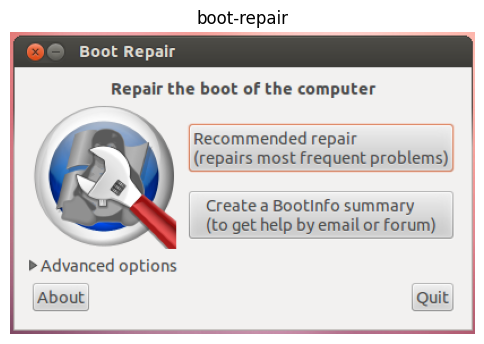

In [3]:
display_image(dataset_cleaned[0])

In [4]:
# Get all unique topics
all_topics = set()
for row in dataset_cleaned:
    if row['topics']:
        all_topics.update(row['topics'])
unique_topics = sorted(list(all_topics))

dataset_cleaned

Dataset({
    features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'screenshots', 'topics', 'image', 'width', 'height'],
    num_rows: 1612
})

In [5]:
# Count slugs per topic
topic_counts = Counter()
for row in dataset_cleaned:
    if row['topics']:
        for topic in row['topics']:
            topic_counts[topic] += 1

image_size_df = dataset_cleaned.select_columns(['slug', 'width', 'height', 'registration_date']).to_pandas()\
    .assign(ratio = lambda x : x['width']/x['height'])
topics_df = pd.DataFrame(topic_counts.items(), columns=['topic', 'count'])

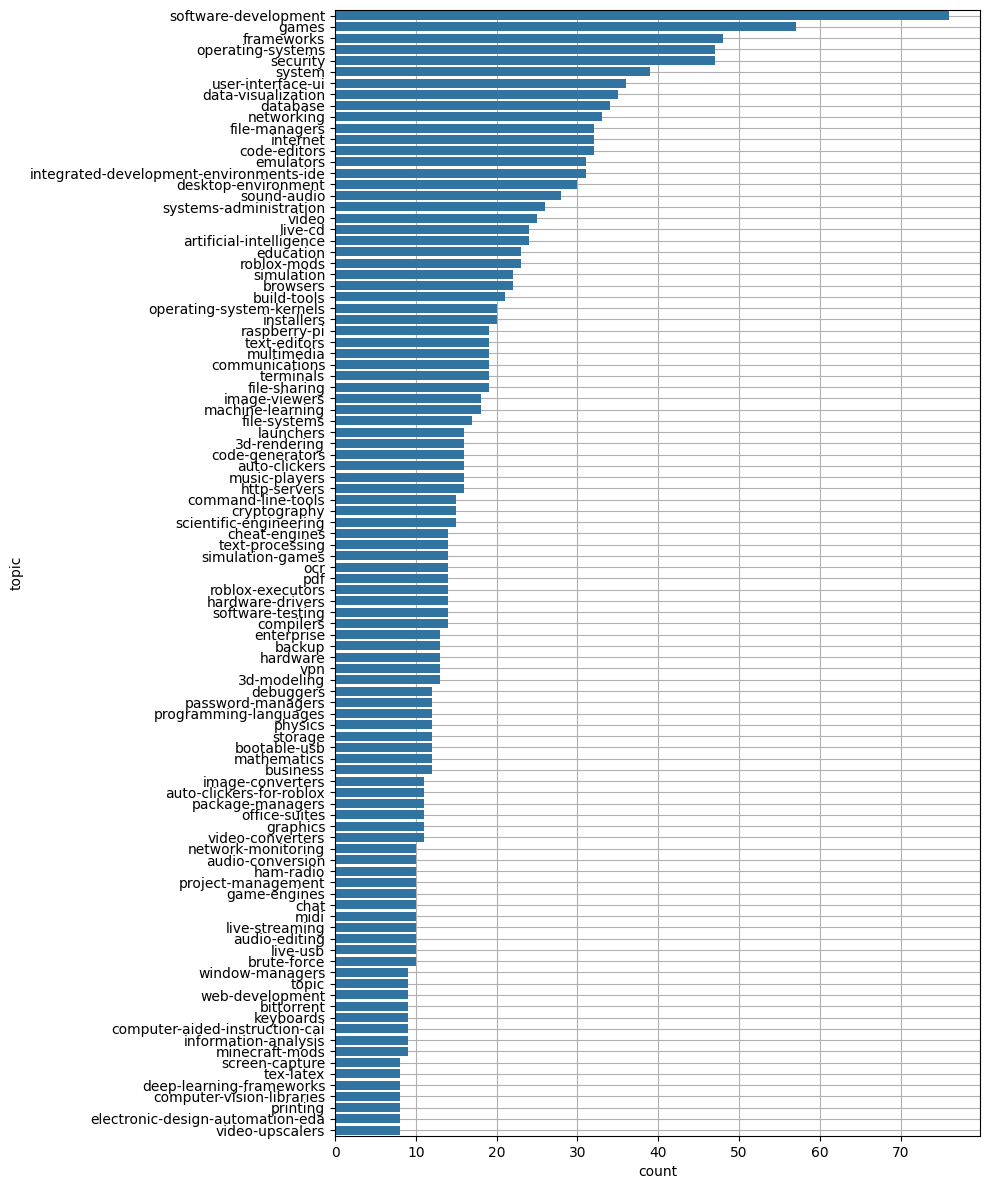

In [6]:
fig, ax= plt.subplots(figsize=(10,12))
N = 100
sns.barplot(topics_df.sort_values("count", ascending=False).head(N), y="topic", x="count", ax=ax)
ax.set_axisbelow(True)
plt.grid()
plt.tight_layout()


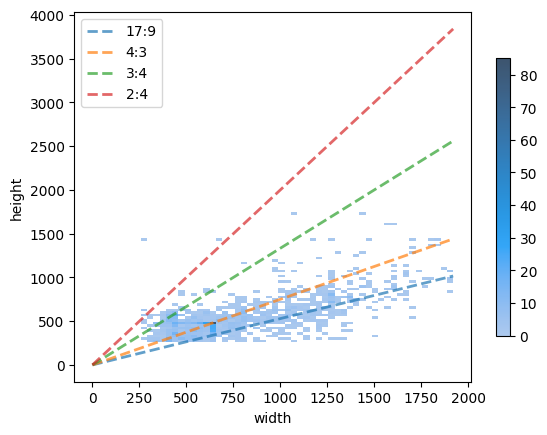

In [7]:
sns.histplot(image_size_df, x="width", y="height", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

max_width = image_size_df["width"].max()
max_height = image_size_df["height"].max()

ratios = {
    "17:9": 17/9,
    "4:3": 4/3,
    "3:4": 3/4,
    "2:4": 2/4,
}

for label, ratio in ratios.items():
    x = np.linspace(0, max_width, 100)
    y = x / ratio
    plt.plot(x, y, linestyle='--', linewidth=2, alpha=0.7, label=label)
plt.legend()


<Axes: xlabel='registration_date', ylabel='ratio'>

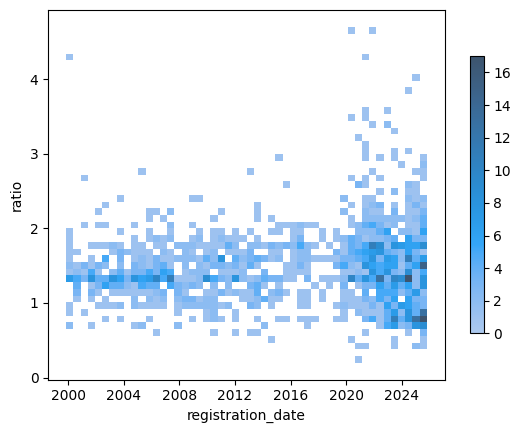

In [8]:
sns.histplot(image_size_df, y="ratio", x="registration_date", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

Text(0.5, 1.0, 'Image Aspect Ratio Distribution')

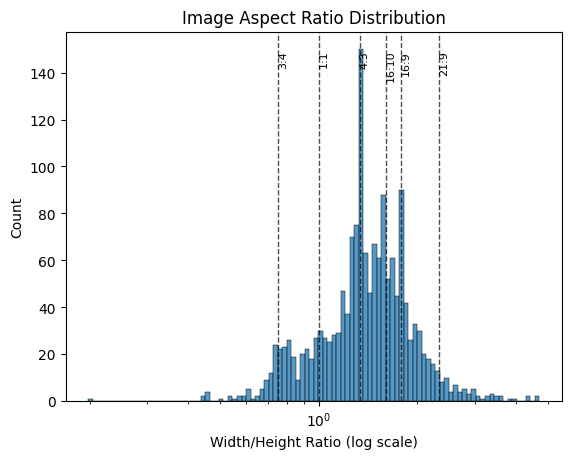

In [9]:
sns.histplot(image_size_df, x="ratio", log_scale=(True, False), bins=100)

typical_ratios = {
    "4:3": 4/3,
    "16:9": 16/9,
    "16:10": 16/10,
    "21:9": 21/9,
    "3:4": 3/4,
    "1:1": 1,
}

for label, ratio in typical_ratios.items():
    plt.axvline(x=ratio, linestyle='--', color='k', alpha=0.7, linewidth=1)
    plt.text(ratio, plt.ylim()[1] * 0.95, label, 
             rotation=90, verticalalignment='top', fontsize=8)

plt.xlabel("Width/Height Ratio (log scale)")
plt.title("Image Aspect Ratio Distribution")

<Axes: xlabel='registration_date', ylabel='Count'>

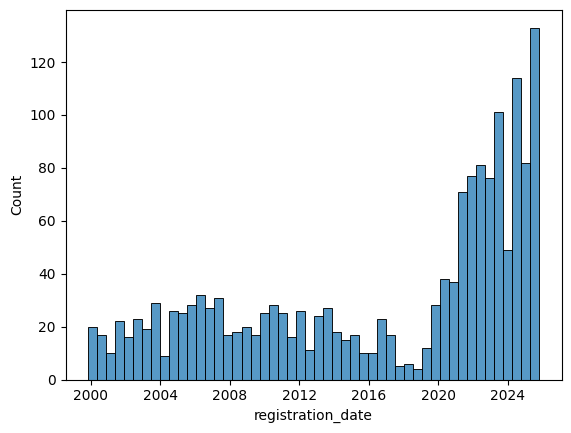

In [10]:
sns.histplot(image_size_df, x="registration_date", bins=50)

In [11]:
slugs_filtered_by_image_size = image_size_df.pipe(lambda x: x[(x["ratio"]>2/4) & (x["ratio"]<17/9)])
slugs_filtered_by_image_size

,slug,width,height,registration_date,ratio
0,boot-repair,411,267,2011-08-11,1.539326
1,codeblocks,635,480,2004-12-20,1.322917
2,crystaldiskinfo,1012,952,2023-08-11,1.063025
3,hwinfo,1126,678,2023-10-05,1.660767
4,infrarecorder,905,647,2006-08-18,1.398764
...,...,...,...,...,...
1607,youtube-vanced-pc,717,600,2018-09-12,1.195000
1608,zbar.mirror,428,281,2024-10-31,1.523132
1609,zekr,640,436,2005-01-10,1.467890
1610,zxw-download,1000,1000,2023-10-15,1.000000


<Axes: xlabel='width', ylabel='height'>

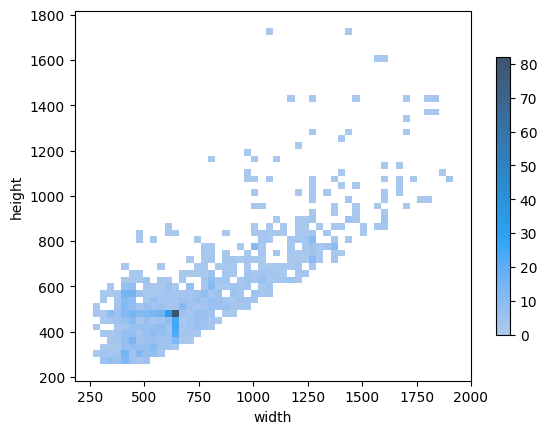

In [12]:
sns.histplot(slugs_filtered_by_image_size, x="width", y="height", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

In [13]:
final_slugs = slugs_filtered_by_image_size["slug"].values
final_dataset = dataset_cleaned.filter(lambda x : x["slug"] in final_slugs).remove_columns(["screenshots"])
final_dataset

Filter: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1612/1612 [00:05<00:00, 304.23 examples/s]


Dataset({
    features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'topics', 'image', 'width', 'height'],
    num_rows: 1393
})

In [14]:
final_dataset.push_to_hub("Vokturz/sourceforge-app-screenshots")

Map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1393/1393 [00:00<00:00, 4148.90 examples/s]

Creating parquet from Arrow format: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 20.68ba/s]
Processing Files (0 / 0): |                                                                                             |  0.00B /  0.00B            
Processing Files (0 / 1):  68%|████████████████████████████████████████████████████████████▋                            |  120MB /  175MB,  149MB/s  
Processing Files (0 / 1):  68%|████████████████████████████████████████████████████████████▉                            |  120MB /  175MB, 60.0MB/s  
Processing Files (0 / 1):  69%|█████████████████████████████████████████████████████████████▏                           |  121MB /  175MB, 43.1MB/s  
Processing Files (0 / 1):  69%|█████████████████████████████████████████████████████████████▍      

CommitInfo(commit_url='https://huggingface.co/datasets/Vokturz/sourceforge-app-screenshots/commit/1a5fc1c70c3e214c5d70104fd7d0bb09c04224e5', commit_message='Upload dataset', commit_description='', oid='1a5fc1c70c3e214c5d70104fd7d0bb09c04224e5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Vokturz/sourceforge-app-screenshots', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Vokturz/sourceforge-app-screenshots'), pr_revision=None, pr_num=None)